In [ ]:
# TODO: 
# implement TabPFN embedding module for comparison, 
# compare with models like XGBoost and NLP only approaches

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from momentfm import MOMENTPipeline

/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [ ]:
ts_path = Path.cwd() / "data" / "time_series"

text_path = Path.cwd() / "data" / "text"

images_path = Path.cwd() / "images"
images_path.mkdir(parents=True, exist_ok=True)

csv_files = sorted(ts_path.glob("*.csv"))

In [7]:
print(f"{len(csv_files)} Ticker(s) found in {ts_path}")

ticker_to_df = {}
n_tickers = 100

for i, csv_file in enumerate(csv_files):

    if i >= n_tickers:
        break

    df = pd.read_csv(csv_file)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
    df = df.dropna(subset=["Date"]).sort_values("Date")
    df["Date"] = df["Date"].dt.tz_convert("UTC").dt.tz_localize(None)
    ticker_to_df[csv_file.stem] = df

4213 Ticker(s) found in /home/rodrigodog/latent_fusion/data/time_series


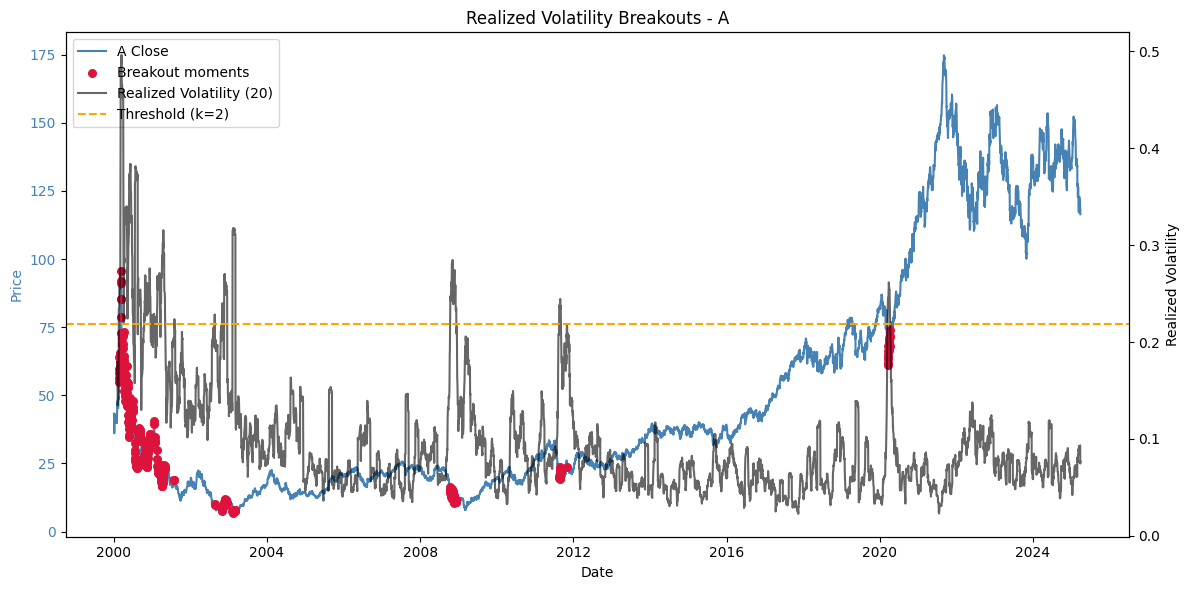

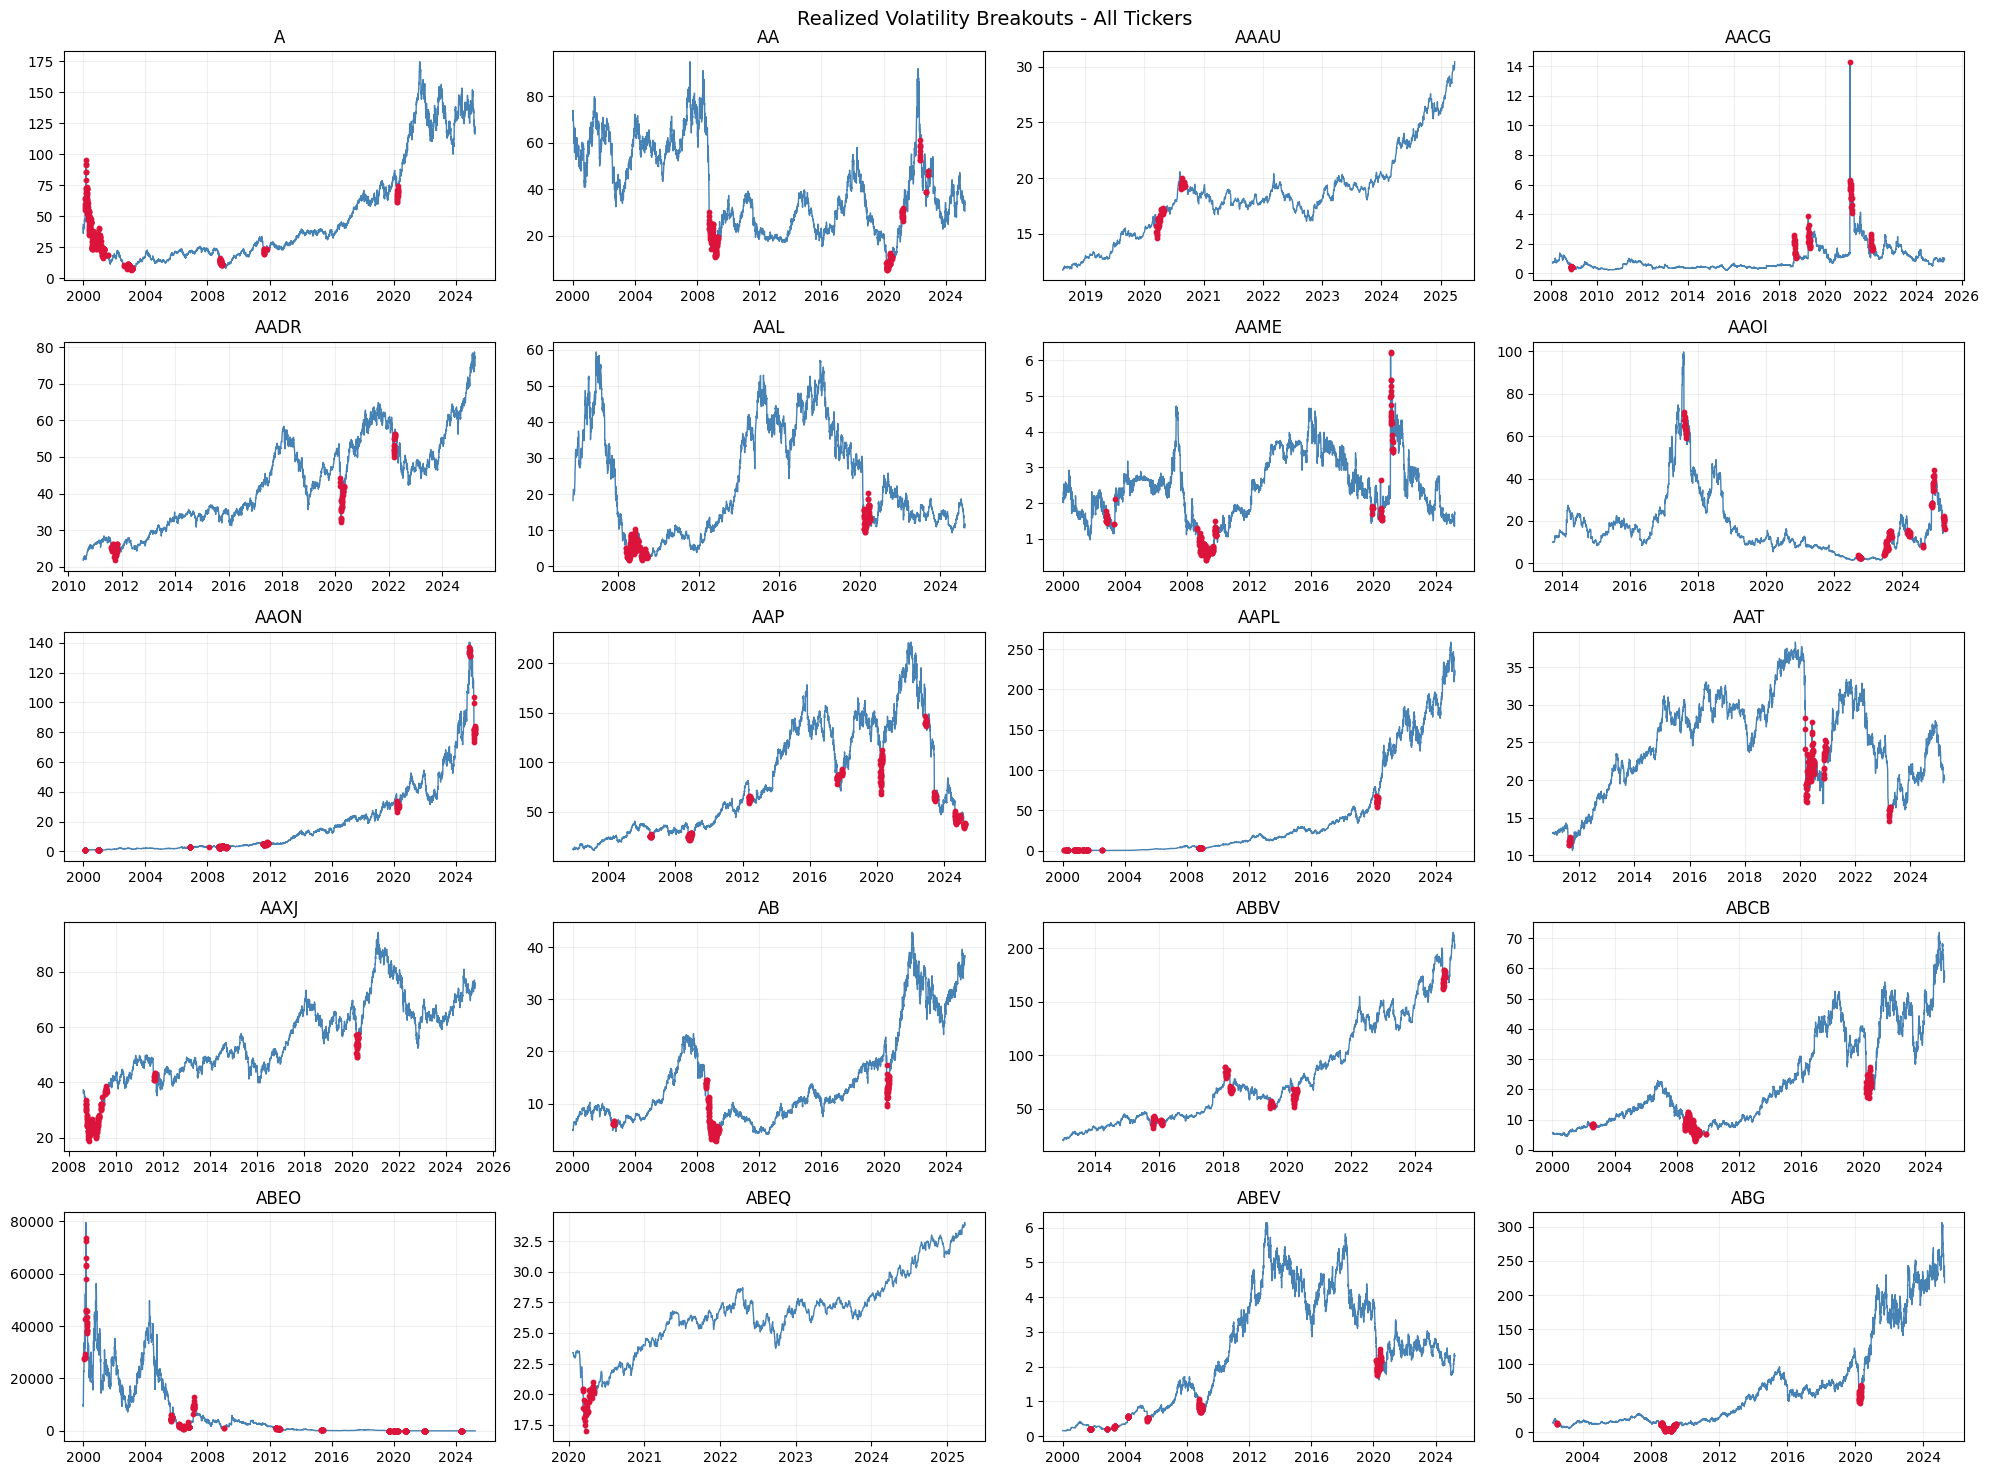

(ticker
 a       362
 abeo    312
 abcb    293
 aal     269
 aaon    264
 aame    243
 aap     238
 abg     237
 ab      228
 aa      209
 abev    192
 aaxj    180
 aapl    172
 aaoi    149
 abbv    147
 aat     123
 aacg    102
 aadr     93
 aaau     53
 abeq     40
 Name: n_breakouts, dtype: int64,
    ticker                date        rv  threshold
 0    aapl 2000-02-01 05:00:00  0.238725   0.214439
 1    abeo 2000-02-01 05:00:00  0.667091   0.556440
 2    aapl 2000-02-02 05:00:00  0.222353   0.214439
 3    abeo 2000-02-02 05:00:00  0.663088   0.556440
 4    aapl 2000-02-03 05:00:00  0.226303   0.214439
 5    abeo 2000-02-03 05:00:00  0.663583   0.556440
 6    abeo 2000-02-04 05:00:00  0.648095   0.556440
 7    abeo 2000-02-07 05:00:00  0.650022   0.556440
 8    aaon 2000-02-09 05:00:00  0.210333   0.197715
 9    aaon 2000-02-10 05:00:00  0.212524   0.197715
 10   aaon 2000-02-11 05:00:00  0.212551   0.197715
 11   aaon 2000-02-14 05:00:00  0.212229   0.197715
 12   aaon 2000-02-15 

In [ ]:
window = 20
k = 2.0

rv_by_ticker = {}
threshold_by_ticker = {}
events_by_ticker = {}
breakout_rows = []

for ticker, df in ticker_to_df.items():
    data = (
        df[["Date", "Close"]]
        .dropna(subset=["Date", "Close"])
        .sort_values("Date")
        .copy()
    )
    price = data["Close"].astype(float)
    if len(price) < window + 1:
        continue

    returns = np.diff(np.log(price.to_numpy()))
    rv = pd.Series(returns**2, index=data["Date"].iloc[1:]).rolling(window).sum()**0.5
    threshold = rv.mean() + k * rv.std()
    events = rv[rv > threshold]

    rv_by_ticker[ticker] = rv
    threshold_by_ticker[ticker] = threshold
    events_by_ticker[ticker] = events

    if not events.empty:
        breakout_rows.extend(
            {"ticker": ticker, "date": dt, "rv": val, "threshold": threshold}
            for dt, val in events.items()
        )

breakout_df = pd.DataFrame(breakout_rows)
if not breakout_df.empty:
    breakout_df = breakout_df.sort_values(["date", "ticker"]).reset_index(drop=True)
breakout_counts = breakout_df.groupby("ticker").size().sort_values(ascending=False).rename("n_breakouts") if not breakout_df.empty else pd.Series(dtype=int)

plot_ticker = breakout_counts.index[0] if not breakout_counts.empty else next(iter(rv_by_ticker))
plot_df = ticker_to_df[plot_ticker][["Date", "Close"]].dropna(subset=["Date", "Close"]).sort_values("Date").copy()
plot_df["Close"] = plot_df["Close"].astype(float)

rv_plot = rv_by_ticker[plot_ticker]
events_plot = events_by_ticker[plot_ticker]
threshold_plot = threshold_by_ticker[plot_ticker]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(plot_df["Date"], plot_df["Close"], color="steelblue", label=f"{plot_ticker.upper()} Close")
if not events_plot.empty:
    y_events = plot_df.set_index("Date").reindex(events_plot.index)["Close"]
    ax1.scatter(events_plot.index, y_events, color="crimson", s=30, label="Breakout moments", zorder=3)
ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(rv_plot.index, rv_plot.values, color="black", alpha=0.6, label="Realized Volatility (20)")
ax2.axhline(threshold_plot, color="orange", linestyle="--", label=f"Threshold (k={k:g})")
ax2.set_ylabel("Realized Volatility", color="black")
ax2.tick_params(axis="y", labelcolor="black")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")
plt.title(f"Realized Volatility Breakouts - {plot_ticker.upper()}")
plt.tight_layout()
plt.show()

all_tickers_rv = sorted(rv_by_ticker.keys())
if all_tickers_rv:
    ncols = 4
    nrows = int(np.ceil(len(all_tickers_rv) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, t in zip(axes, all_tickers_rv):
        d = ticker_to_df[t][["Date", "Close"]].dropna(subset=["Date", "Close"]).sort_values("Date").copy()
        d["Close"] = d["Close"].astype(float)
        ax.plot(d["Date"], d["Close"], color="steelblue", linewidth=1.0)
        ev = events_by_ticker.get(t, pd.Series(dtype=float))
        if not ev.empty:
            ev_prices = d.set_index("Date").reindex(ev.index)["Close"]
            ax.scatter(ev.index, ev_prices, color="crimson", s=10, zorder=3)
        ax.set_title(t.upper())
        ax.grid(True, alpha=0.2)

    for ax in axes[len(all_tickers_rv):]:
        ax.axis("off")

    fig.suptitle("Realized Volatility Breakouts - All Tickers", fontsize=14)
    fig.tight_layout()
    plt.show()

breakout_counts.head(20), breakout_df.head(30)

In [7]:
from momentfm import MOMENTPipeline

model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large", 
    model_kwargs={
        "task_name": "embedding"
    },
)
model.init()

/home/rodrigodog/ic/.venv/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


In [8]:
import os
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from openai import OpenAI
from sklearn.decomposition import PCA

context_length = 60
n_channels = 1

valid_tickers = []
series_list = []
moment_window_dates = {}

for ticker, df in ticker_to_df.items():
    d = (
        df[["Date", "Close"]]
        .dropna(subset=["Date", "Close"])
        .sort_values("Date")
        .copy()
    )
    d["Close"] = d["Close"].astype(float)
    if len(d) >= context_length:
        window = d.tail(context_length)
        valid_tickers.append(ticker)
        series_list.append(window["Close"].to_numpy())
        moment_window_dates[ticker] = window["Date"].dt.normalize().reset_index(drop=True)

x_np = np.stack(series_list, axis=0)
x_enc = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    out = model(x_enc=x_enc)

if isinstance(out, dict):
    emb = out.get("embeddings", None)
    if emb is None:
        emb = out.get("repr", None)
    if emb is None:
        emb = out.get("representation", None)
    if emb is None:
        emb = next(v for v in out.values() if torch.is_tensor(v))
elif hasattr(out, "embeddings"):
    emb = out.embeddings
elif torch.is_tensor(out):
    emb = out
elif isinstance(out, (list, tuple)) and len(out) > 0 and torch.is_tensor(out[0]):
    emb = out[0]
else:
    raise ValueError("Could not extract embeddings from model output")embeddings_df

emb_2d_input = emb.detach().cpu().reshape(emb.shape[0], -1).numpy()
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb_2d_input)

embeddings_df = pd.DataFrame({
    "ticker": valid_tickers,
    "pc1": emb_2d[:, 0],
    "pc2": emb_2d[:, 1],
})

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set")

client = OpenAI(api_key=api_key)
text_dir = Path.cwd() / "data" / "text"
text_embedding_model = "text-embedding-3-small"
text_embedding_dim = 512

aligned_rows = []
for ticker in valid_tickers:
    jsonl_path = text_dir / f"{ticker.upper()}.jsonl"
    if not jsonl_path.exists():
        jsonl_path = text_dir / f"{ticker}.jsonl"

    if jsonl_path.exists():
        news = pd.read_json(jsonl_path, lines=True)
        if "Date" in news.columns and "Article" in news.columns:
            news = news[["Date", "Article"]].copy()
            news["Date"] = pd.to_datetime(news["Date"], errors="coerce").dt.normalize()
            news = news.dropna(subset=["Date", "Article"])
            news["Article"] = news["Article"].astype(str)
        else:
            news = pd.DataFrame(columns=["Date", "Article"])
    else:
        news = pd.DataFrame(columns=["Date", "Article"])

    for dt in moment_window_dates[ticker]:
        if news.empty:
            txt = ""
        else:
            day_articles = news.loc[news["Date"] == dt, "Article"].tolist()
            txt = " ".join(day_articles)
        txt = txt[:8000]
        aligned_rows.append({"ticker": ticker, "date": dt, "text": txt})

text_alignment_df = pd.DataFrame(aligned_rows)

texts = text_alignment_df["text"].fillna("").astype(str).tolist()
non_empty_indices = [i for i, t in enumerate(texts) if t.strip()]
text_vectors = [None] * len(texts)

batch_size = 128
for start in range(0, len(non_empty_indices), batch_size):
    batch_indices = non_empty_indices[start:start + batch_size]
    batch_input = [texts[i] for i in batch_indices]
    response = client.embeddings.create(
        model=text_embedding_model,
        input=batch_input,
        dimensions=text_embedding_dim,
    )
    for j, item in enumerate(response.data):
        text_vectors[batch_indices[j]] = np.array(item.embedding, dtype=np.float32)

for i in range(len(text_vectors)):
    if text_vectors[i] is None:
        text_vectors[i] = np.zeros(text_embedding_dim, dtype=np.float32)

text_alignment_df["text_embedding"] = text_vectors

text_embedding_np = np.stack(text_alignment_df["text_embedding"].to_list(), axis=0)
text_embedding_np = text_embedding_np.reshape(len(valid_tickers), context_length, text_embedding_dim)
aligned_text_embeddings = torch.tensor(text_embedding_np, dtype=torch.float32)
text_embeddings_per_ticker = aligned_text_embeddings.mean(dim=1)

moment_flat = emb.detach().cpu().reshape(emb.shape[0], -1)
fusion_embeddings = torch.cat([moment_flat, text_embeddings_per_ticker], dim=1)

x_enc.shape, emb.shape, aligned_text_embeddings.shape, fusion_embeddings.shape, embeddings_df.head(), text_alignment_df.head()

/home/rodrigodog/ic/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/rodrigodog/ic/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


(torch.Size([20, 1, 60]),
 torch.Size([20, 1024]),
 torch.Size([20, 60, 512]),
 torch.Size([20, 1536]),
   ticker       pc1       pc2
 0      a  0.102048 -0.288544
 1     aa  0.373825  0.229040
 2   aaau -0.483396  0.027865
 3   aacg -0.115601  0.796030
 4   aadr -0.385333  0.154074,
   ticker       date text                                     text_embedding
 0      a 2024-12-31       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
 1      a 2025-01-02       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
 2      a 2025-01-03       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
 3      a 2025-01-06       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
 4      a 2025-01-07       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...)

In [12]:
aligned_text_embeddings

tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0270,  0.0188,  0.0751,  ...,  0.0721, -0.0222,  0.0438],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0508, -0.0115, -0.0039,  ...,  0.0499,  0.0083, -0.0207]],

        [[ 0.0550, -0.0687, -0.0013,  ...,  0.0685,  0.0164,  0.0521],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0162, -0.0437,  0.0325,  ...,  0.0660,  0.0437, -0.0221],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0691, -0.0044,  0.0292,  ...,  0.0525,  0.0190,  0.0556],
         [-0.0157, -0.0076,  0.0227,  ...,  0.1071,  0.0043, -0.0042]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0

/home/rodrigodog/ic/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/rodrigodog/ic/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


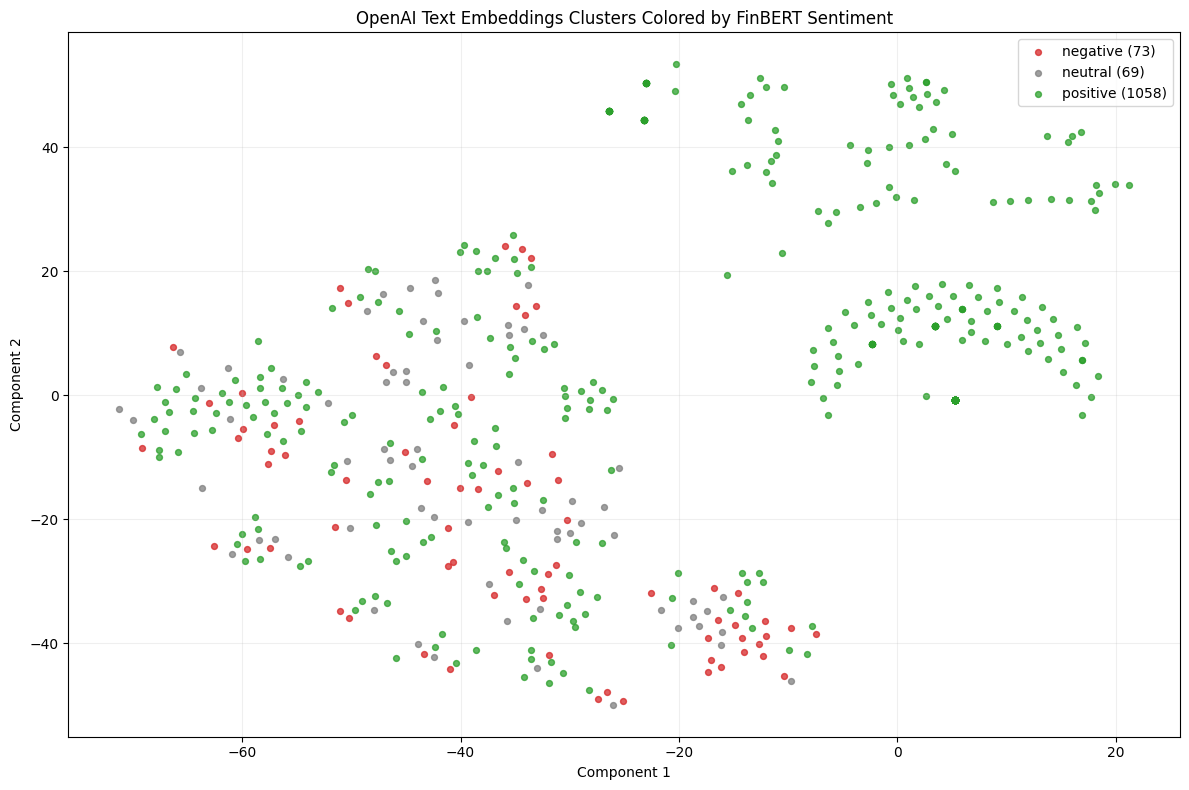

(   ticker       date sentiment  sentiment_confidence          x          y
 0       a 2024-12-31  positive              0.424185  -2.760428  37.519203
 1       a 2025-01-02  positive              0.424185  13.728785  41.832462
 2       a 2025-01-03  positive              0.424185 -11.164700  42.891411
 3       a 2025-01-06  positive              0.424185  -4.383394  40.316223
 4       a 2025-01-07  positive              0.424185   1.475692  31.478949
 5       a 2025-01-08  positive              0.424185  -0.733864  33.568382
 6       a 2025-01-10  positive              0.424185  -6.372673  27.801611
 7       a 2025-01-13  positive              0.424185  -2.715632  39.620132
 8       a 2025-01-14  positive              0.424185 -10.384508  49.723251
 9       a 2025-01-15  positive              0.933782 -53.994801 -26.669653
 10      a 2025-01-16   neutral              0.962002 -60.947197 -25.600576
 11      a 2025-01-17  positive              0.424185 -12.564679  51.262051
 12      a 2

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

cluster_df = text_alignment_df[["ticker", "date", "text", "text_embedding"]].copy()
cluster_df["text"] = cluster_df["text"].fillna("").astype(str)
cluster_df["text_embedding"] = cluster_df["text_embedding"].apply(lambda v: np.asarray(v, dtype=np.float32))

x_text = np.stack(cluster_df["text_embedding"].to_list(), axis=0)

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)
finbert_model.eval()

label_map = {0: "negative", 1: "neutral", 2: "positive"}
all_probs = []
batch_size = 16

with torch.no_grad():
    texts = cluster_df["text"].tolist()
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=512)
        outputs = finbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        all_probs.append(probs)

probs_np = np.vstack(all_probs)
cluster_df["negative"] = probs_np[:, 0]
cluster_df["neutral"] = probs_np[:, 1]
cluster_df["positive"] = probs_np[:, 2]
cluster_df["sentiment"] = [label_map[i] for i in probs_np.argmax(axis=1)]
cluster_df["sentiment_confidence"] = probs_np.max(axis=1)

if x_text.shape[0] > 3:
    pca_dims = min(50, x_text.shape[1], x_text.shape[0] - 1)
    x_for_tsne = PCA(n_components=pca_dims, random_state=42).fit_transform(x_text)
    x_2d = TSNE(n_components=2, perplexity=min(30, max(5, x_text.shape[0] // 4)), random_state=42, init="pca", learning_rate="auto").fit_transform(x_for_tsne)
else:
    x_2d = PCA(n_components=2, random_state=42).fit_transform(x_text)

cluster_df["x"] = x_2d[:, 0]
cluster_df["y"] = x_2d[:, 1]

color_map = {"negative": "#d62728", "neutral": "#7f7f7f", "positive": "#2ca02c"}

plt.figure(figsize=(12, 8))
for label in ["negative", "neutral", "positive"]:
    d = cluster_df[cluster_df["sentiment"] == label]
    if not d.empty:
        plt.scatter(d["x"], d["y"], c=color_map[label], label=f"{label} ({len(d)})", alpha=0.75, s=18)

plt.title("OpenAI Text Embeddings Clusters Colored by FinBERT Sentiment")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

cluster_df[["ticker", "date", "sentiment", "sentiment_confidence", "x", "y"]].head(30), cluster_df["sentiment"].value_counts()

/home/rodrigodog/ic/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


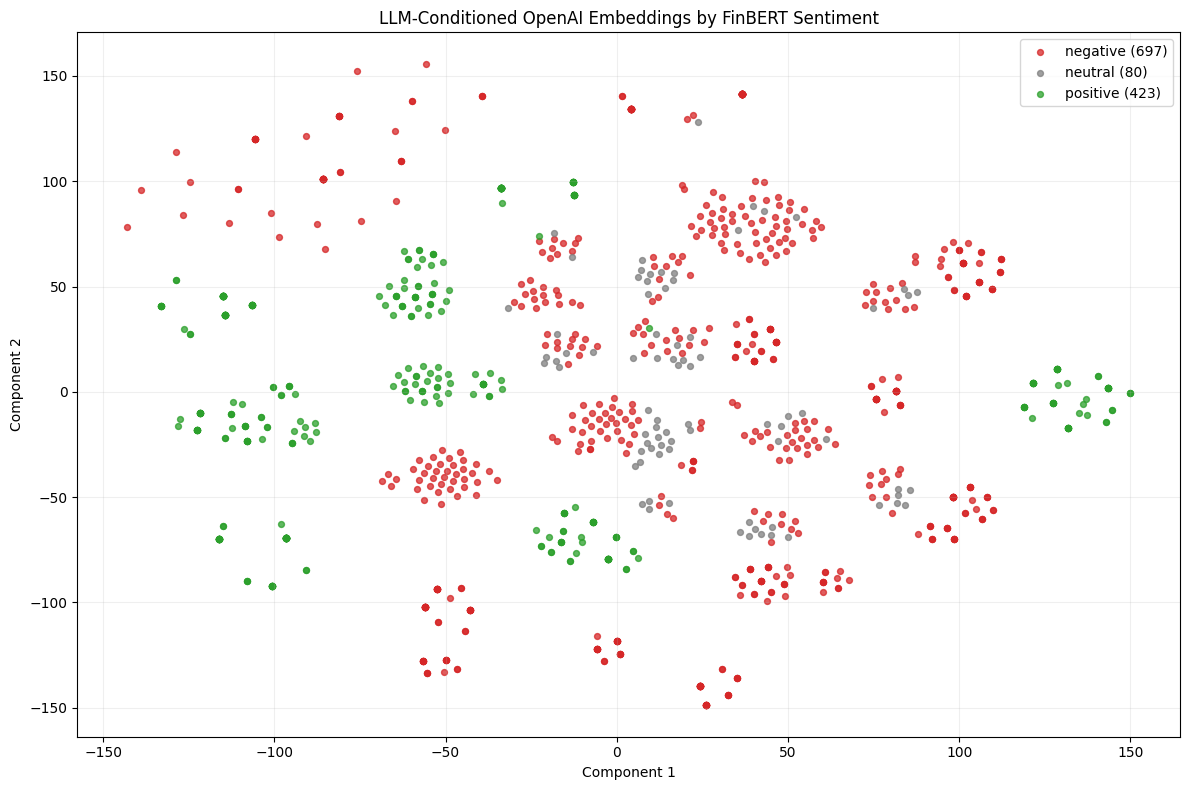

(   ticker       date sentiment  sentiment_confidence          x          y  \
 0       a 2024-12-31  negative              0.494796 -51.432533 -53.499672   
 1       a 2025-01-02  negative              0.494796 -56.384514 -51.275692   
 2       a 2025-01-03  negative              0.494796 -37.338730 -37.484695   
 3       a 2025-01-06  negative              0.494796 -51.013653 -27.619640   
 4       a 2025-01-07  negative              0.494796 -40.978245 -49.285561   
 5       a 2025-01-08  negative              0.494796 -46.680569 -49.567322   
 6       a 2025-01-10  negative              0.494796 -59.588436 -36.705582   
 7       a 2025-01-13  negative              0.494796 -45.644951 -28.415749   
 8       a 2025-01-14  negative              0.494796 -58.264645 -46.252834   
 9       a 2025-01-15  negative              0.836004  10.175491  43.178089   
 10      a 2025-01-16   neutral              0.964719   8.830999  52.429863   
 11      a 2025-01-17  negative              0.49479

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from openai import OpenAI
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set")

client = OpenAI(api_key=api_key)

llm_cluster_df = text_alignment_df[["ticker", "date", "text"]].copy()
llm_cluster_df["text"] = llm_cluster_df["text"].fillna("").astype(str)

analysis_model = "gpt-4.1-mini"
embedding_model = "text-embedding-3-small"
embedding_dim = 512

def build_firm_prompt(ticker, date_str, raw_text):
    return f"""You are a professional equity research analyzer for an institutional investment firm.
Write a firm-specific analyst memo for {ticker.upper()} based on the news below.
Date: {date_str}
News:
{raw_text if raw_text.strip() else 'No concrete article text was provided for this date.'}

Return exactly 10 concise bullet points focused on {ticker.upper()}:
- what this means for this specific firm
- business segment impact
- near-term catalysts
- medium-term risks
- earnings and margin implications
- balance sheet or liquidity implications
- competitive positioning
- regulatory or macro sensitivity
- sentiment direction with confidence
- 1-3 month investment takeaway
"""

memo_cache = {}
memos = []

for row in llm_cluster_df.itertuples(index=False):
    ticker = str(row.ticker)
    date_str = pd.Timestamp(row.date).strftime("%Y-%m-%d")
    raw_text = str(row.text)
    cache_key = (ticker, raw_text.strip())

    if cache_key in memo_cache:
        memo = memo_cache[cache_key]
    else:
        prompt = build_firm_prompt(ticker=ticker, date_str=date_str, raw_text=raw_text[:8000])
        completion = client.chat.completions.create(
            model=analysis_model,
            temperature=0.2,
            messages=[
                {"role": "system", "content": "You are a rigorous, concise buy-side equity research analyst."},
                {"role": "user", "content": prompt},
            ],
        )
        memo = completion.choices[0].message.content or ""
        memo_cache[cache_key] = memo

    memos.append(memo)

llm_cluster_df["firm_memo"] = memos

memo_texts = llm_cluster_df["firm_memo"].fillna("").astype(str).tolist()
non_empty_idx = [i for i, t in enumerate(memo_texts) if t.strip()]
memo_vectors = [None] * len(memo_texts)

batch_size = 128
for start in range(0, len(non_empty_idx), batch_size):
    batch_idx = non_empty_idx[start:start + batch_size]
    batch_input = [memo_texts[i] for i in batch_idx]
    response = client.embeddings.create(
        model=embedding_model,
        input=batch_input,
        dimensions=embedding_dim,
    )
    for j, item in enumerate(response.data):
        memo_vectors[batch_idx[j]] = np.asarray(item.embedding, dtype=np.float32)

for i in range(len(memo_vectors)):
    if memo_vectors[i] is None:
        memo_vectors[i] = np.zeros(embedding_dim, dtype=np.float32)

llm_cluster_df["memo_embedding"] = memo_vectors
x_text = np.stack(llm_cluster_df["memo_embedding"].to_list(), axis=0)

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)
finbert_model.eval()

all_probs = []
sent_batch_size = 16

with torch.no_grad():
    for i in range(0, len(memo_texts), sent_batch_size):
        batch_texts = memo_texts[i:i + sent_batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=512)
        outputs = finbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        all_probs.append(probs)

probs_np = np.vstack(all_probs)
label_map = {0: "negative", 1: "neutral", 2: "positive"}
llm_cluster_df["negative"] = probs_np[:, 0]
llm_cluster_df["neutral"] = probs_np[:, 1]
llm_cluster_df["positive"] = probs_np[:, 2]
llm_cluster_df["sentiment"] = [label_map[i] for i in probs_np.argmax(axis=1)]
llm_cluster_df["sentiment_confidence"] = probs_np.max(axis=1)

if x_text.shape[0] > 3:
    pca_dims = min(50, x_text.shape[1], x_text.shape[0] - 1)
    x_for_tsne = PCA(n_components=pca_dims, random_state=42).fit_transform(x_text)
    perplexity = min(30, max(5, x_text.shape[0] // 4))
    x_2d = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca", learning_rate="auto").fit_transform(x_for_tsne)
else:
    x_2d = PCA(n_components=2, random_state=42).fit_transform(x_text)

llm_cluster_df["x"] = x_2d[:, 0]
llm_cluster_df["y"] = x_2d[:, 1]

color_map = {"negative": "#d62728", "neutral": "#7f7f7f", "positive": "#2ca02c"}

plt.figure(figsize=(12, 8))
for label in ["negative", "neutral", "positive"]:
    d = llm_cluster_df[llm_cluster_df["sentiment"] == label]
    if not d.empty:
        plt.scatter(d["x"], d["y"], c=color_map[label], label=f"{label} ({len(d)})", alpha=0.75, s=18)

plt.title("LLM-Conditioned OpenAI Embeddings by FinBERT Sentiment")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

llm_cluster_df[["ticker", "date", "sentiment", "sentiment_confidence", "x", "y", "firm_memo"]].head(20), llm_cluster_df["sentiment"].value_counts()

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from openai import OpenAI
from sklearn.decomposition import PCA

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set")

client = OpenAI(api_key=api_key)

if "text_alignment_df" in globals() and isinstance(text_alignment_df, pd.DataFrame) and len(text_alignment_df) > 0:
    llm_cluster_df = text_alignment_df[["ticker", "date", "text"]].copy()
else:
    text_dir = Path.cwd() / "data" / "text"
    jsonl_files = sorted(text_dir.glob("*.jsonl"))
    if not jsonl_files:
        raise ValueError("No JSONL files found in data/text")

    aligned_rows = []
    for jsonl_path in jsonl_files:
        ticker = jsonl_path.stem
        news = pd.read_json(jsonl_path, lines=True)

        if "Date" not in news.columns:
            continue
        text_col = "Article" if "Article" in news.columns else ("text" if "text" in news.columns else None)
        if text_col is None:
            continue

        news = news[["Date", text_col]].copy()
        news["Date"] = pd.to_datetime(news["Date"], errors="coerce").dt.normalize()
        news[text_col] = news[text_col].fillna("").astype(str)
        news = news.dropna(subset=["Date"])
        if news.empty:
            continue

        daily = news.groupby("Date", as_index=False)[text_col].agg(lambda s: " ".join(s.tolist())[:8000])
        daily = daily.rename(columns={"Date": "date", text_col: "text"})
        daily["ticker"] = ticker
        aligned_rows.extend(daily[["ticker", "date", "text"]].to_dict("records"))

    llm_cluster_df = pd.DataFrame(aligned_rows)
    if llm_cluster_df.empty:
        raise ValueError("Could not build text dataset from data/text JSONL files")

llm_cluster_df["text"] = llm_cluster_df["text"].fillna("").astype(str)

embedding_model = "text-embedding-3-small"
embedding_dim = 512

texts = llm_cluster_df["text"].tolist()
non_empty_idx = [i for i, t in enumerate(texts) if t.strip()]
emb_vectors = [None] * len(texts)

batch_size = 128
for start in range(0, len(non_empty_idx), batch_size):
    batch_idx = non_empty_idx[start:start + batch_size]
    batch_input = [texts[i] for i in batch_idx]
    response = client.embeddings.create(
        model=embedding_model,
        input=batch_input,
        dimensions=embedding_dim,
    )
    for j, item in enumerate(response.data):
        emb_vectors[batch_idx[j]] = np.asarray(item.embedding, dtype=np.float32)

for i in range(len(emb_vectors)):
    if emb_vectors[i] is None:
        emb_vectors[i] = np.zeros(embedding_dim, dtype=np.float32)

llm_cluster_df["memo_embedding"] = emb_vectors
x_text = np.stack(llm_cluster_df["memo_embedding"].to_list(), axis=0)

if x_text.shape[0] > 2:
    x_2d = PCA(n_components=2, random_state=42).fit_transform(x_text)
else:
    x_2d = np.zeros((x_text.shape[0], 2), dtype=np.float32)

llm_cluster_df["x"] = x_2d[:, 0]
llm_cluster_df["y"] = x_2d[:, 1]

llm_cluster_df[["ticker", "date", "x", "y", "memo_embedding"]].head(20)

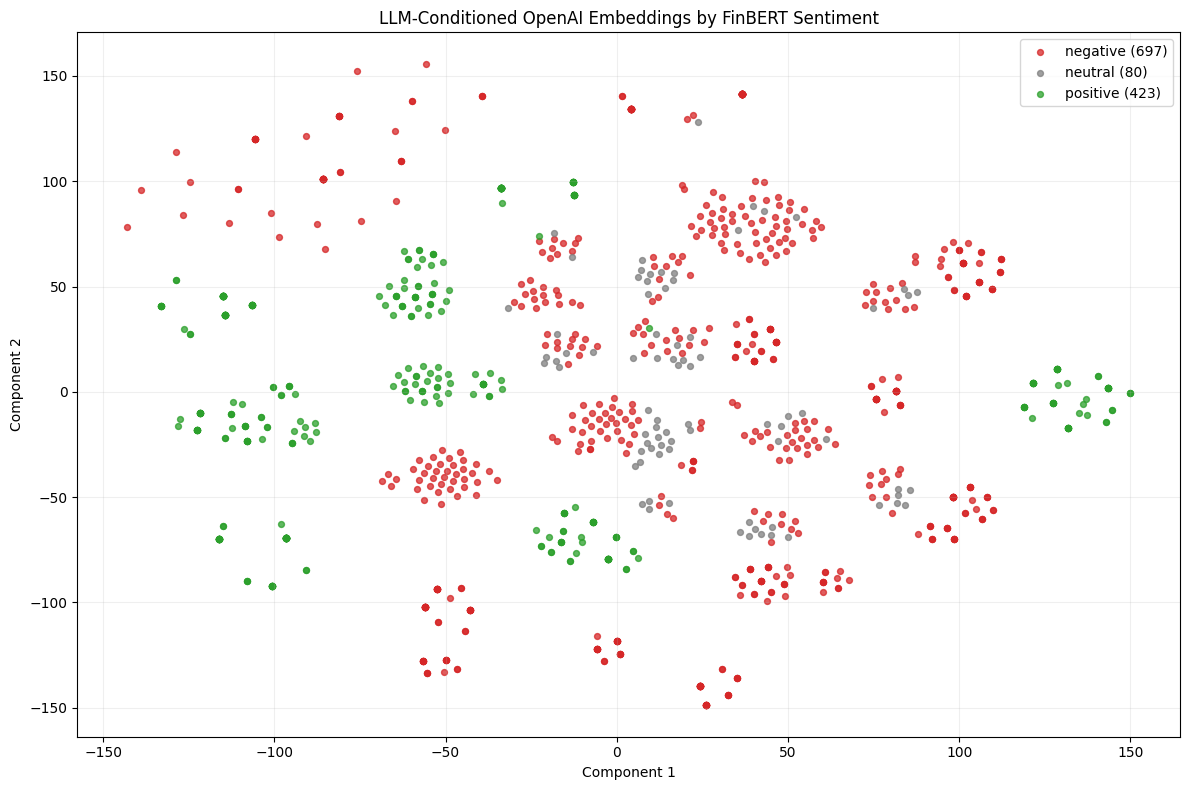

In [15]:
plt.figure(figsize=(12, 8))
for label in ["negative", "neutral", "positive"]:
    d = llm_cluster_df[llm_cluster_df["sentiment"] == label]
    if not d.empty:
        plt.scatter(d["x"], d["y"], c=color_map[label], label=f"{label} ({len(d)})", alpha=0.75, s=18)

plt.title("LLM-Conditioned OpenAI Embeddings by FinBERT Sentiment")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(images_path / "llm_conditioned_embeddings.png", dpi=300)

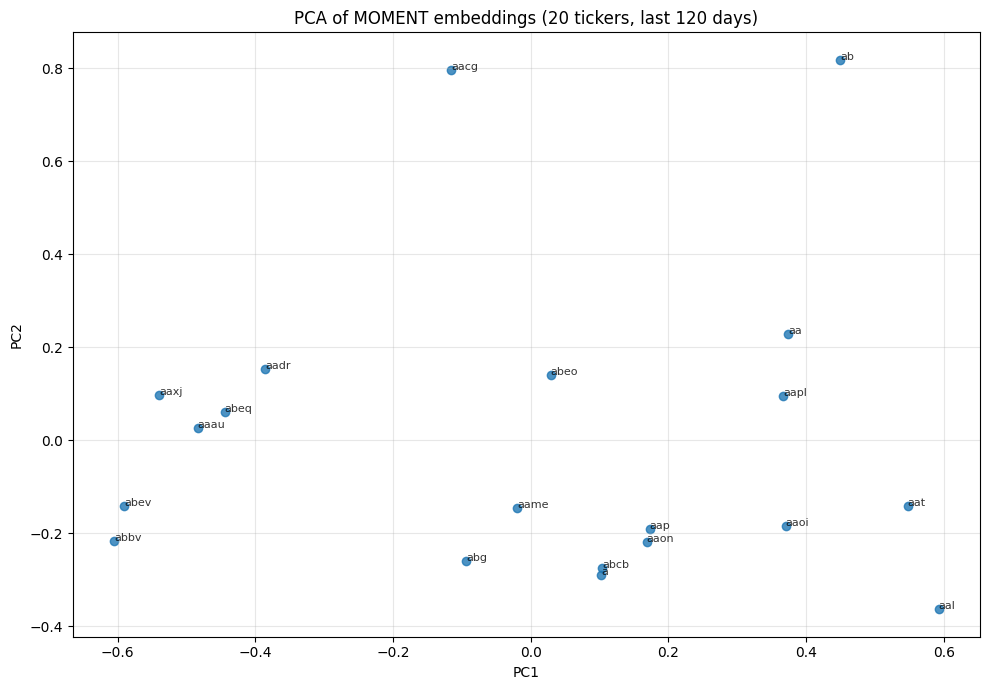

,ticker,pc1,pc2
0,a,0.102048,-0.288544
1,aa,0.373825,0.229040
2,aaau,-0.483396,0.027865
3,aacg,-0.115601,0.796030
4,aadr,-0.385333,0.154074
5,aal,0.592689,-0.363008
6,aame,-0.019648,-0.145050
7,aaoi,0.370177,-0.184111
8,aaon,0.168226,-0.217431
9,aap,0.173089,-0.190175


In [16]:
plt.figure(figsize=(10, 7))
plt.scatter(embeddings_df["pc1"], embeddings_df["pc2"], alpha=0.8)

for _, r in embeddings_df.iterrows():
    plt.text(r["pc1"], r["pc2"], r["ticker"], fontsize=8, alpha=0.8)

plt.title("PCA of MOMENT embeddings (20 tickers, last 120 days)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_path / "moment_embeddings_pca.png", dpi=300)
plt.show()

embeddings_df



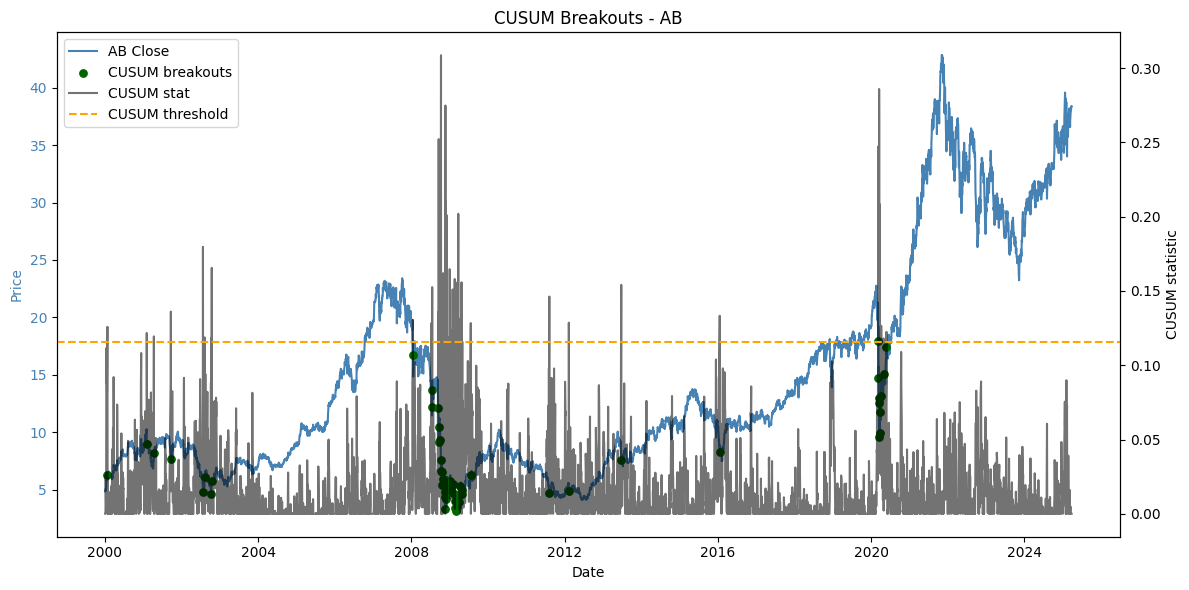

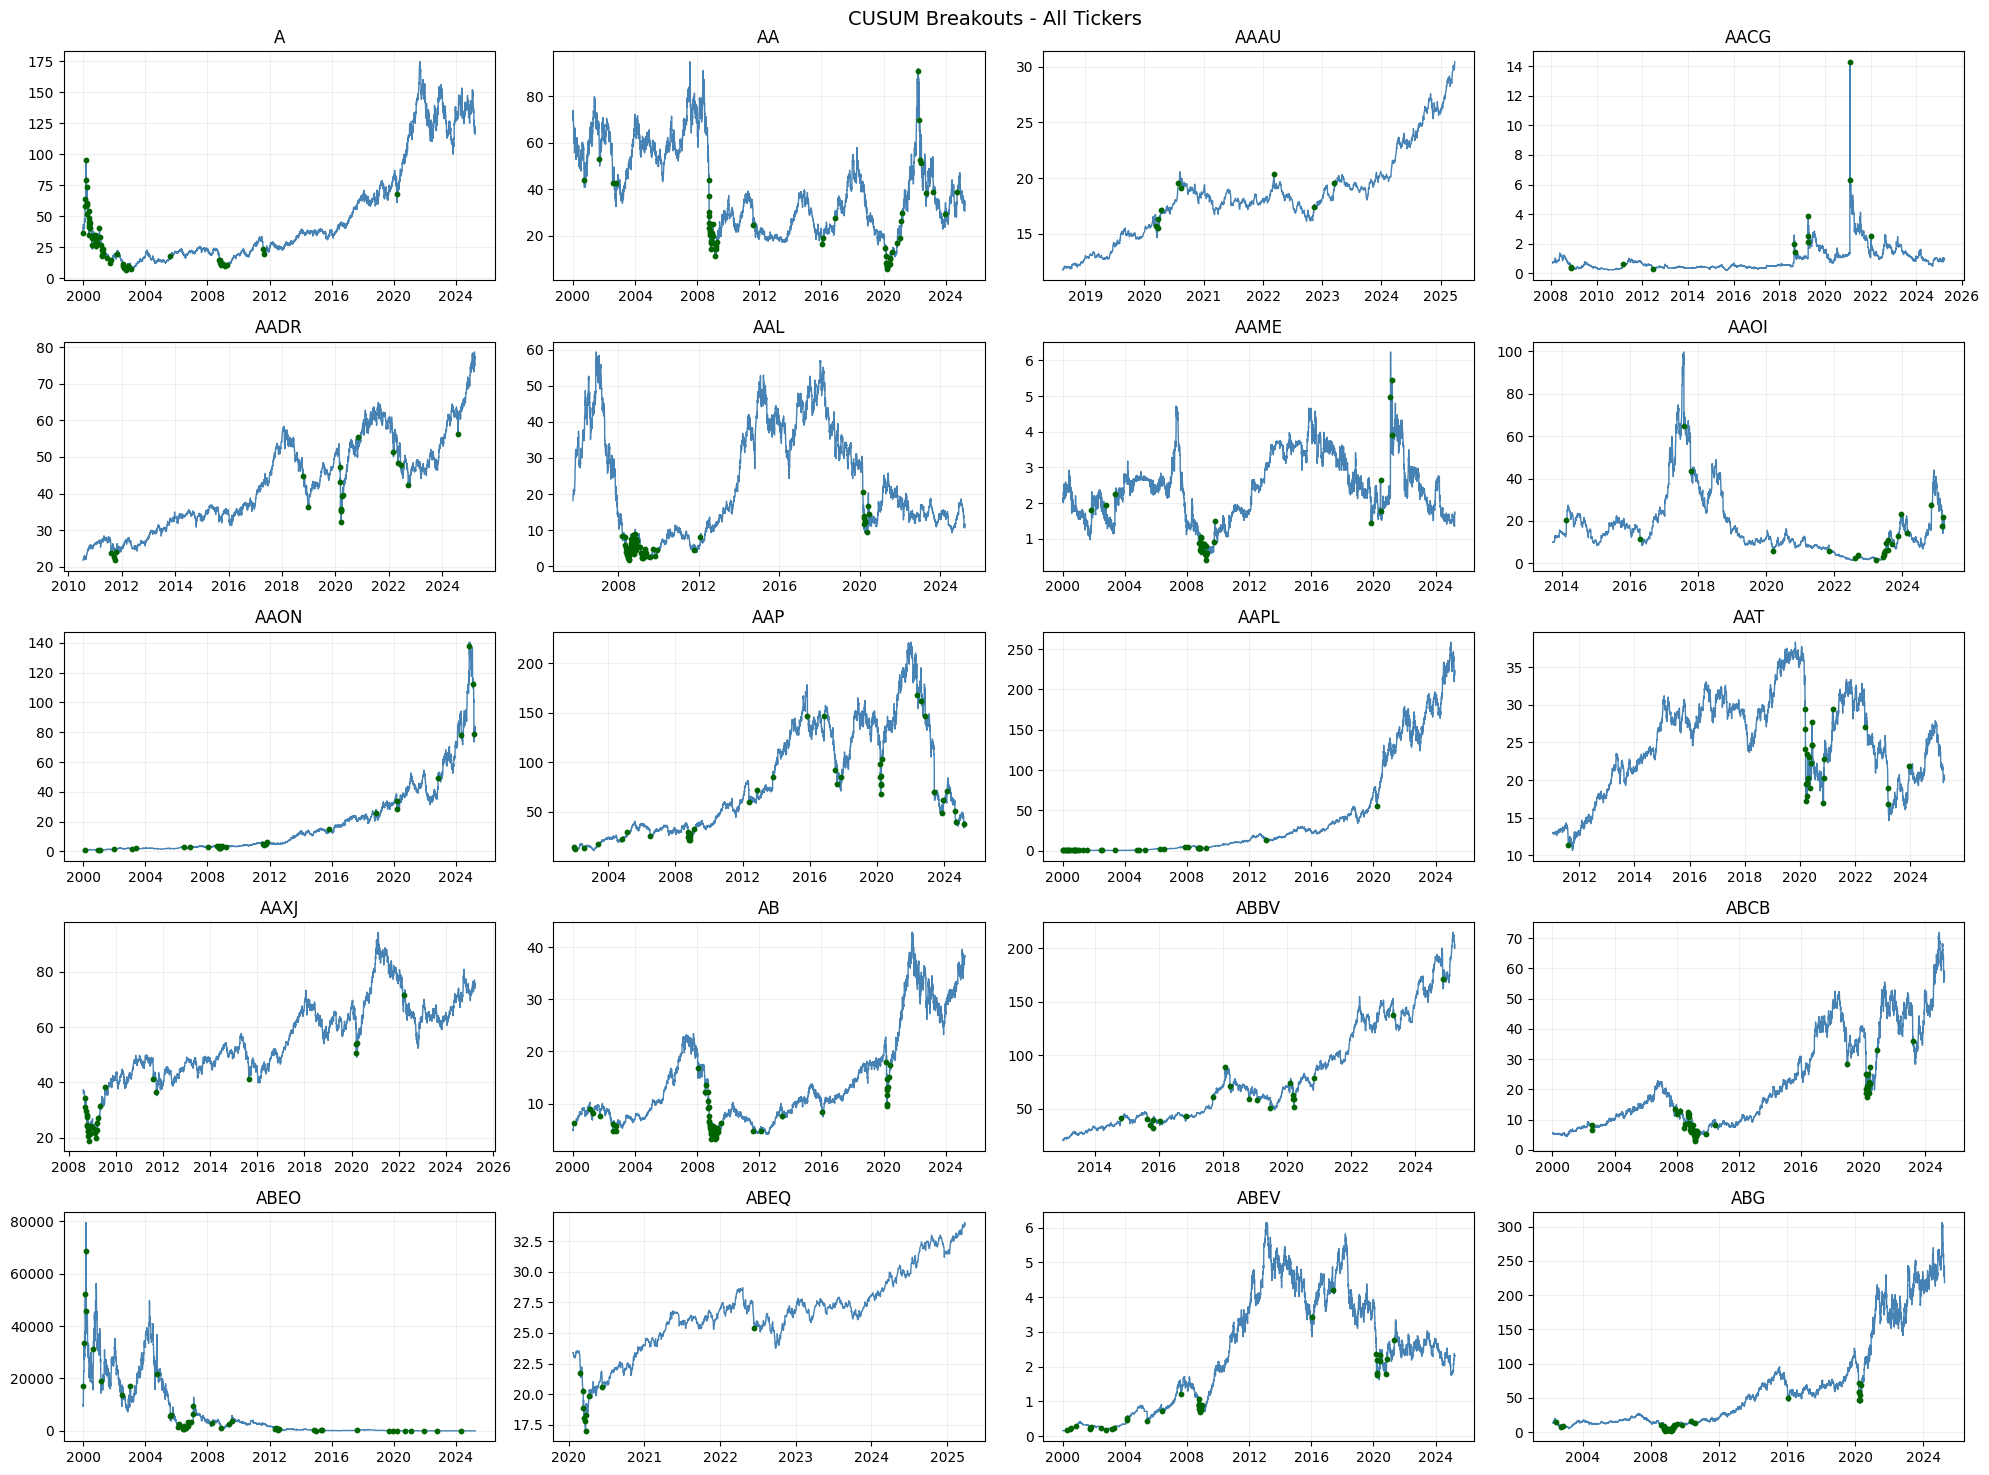

(ticker
 ab      57
 a       56
 abcb    54
 aa      53
 aal     51
 abg     50
 abeo    48
 aap     41
 abev    38
 aapl    36
 aaxj    34
 aaon    32
 aame    30
 aat     24
 aaoi    23
 abbv    21
 aadr    20
 aacg    12
 abeq    10
 aaau     9
 Name: n_breakouts, dtype: int64,
    ticker                date         price  cusum_stat  threshold
 0       a 2000-01-06 05:00:00     36.075714    0.144198   0.127079
 1    aapl 2000-01-06 05:00:00      0.714723    0.126270   0.125980
 2    abeo 2000-01-10 05:00:00  17189.474609    0.513521   0.331945
 3    aapl 2000-01-18 05:00:00      0.781963    0.137934   0.125980
 4      ab 2000-01-24 05:00:00      6.293240    0.125889   0.115728
 5    abeo 2000-01-24 05:00:00  33662.718750    0.406537   0.331945
 6    aaon 2000-02-10 05:00:00      0.897320    0.136232   0.128155
 7       a 2000-02-17 05:00:00     58.322407    0.217016   0.127079
 8    abeo 2000-02-22 05:00:00  52284.648438    0.373492   0.331945
 9       a 2000-02-24 05:00:00     64.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cusum_breakout_rows = []
cusum_stat_by_ticker = {}
cusum_events_by_ticker = {}

for ticker, df in ticker_to_df.items():
    data = df[["Date", "Close"]].dropna(subset=["Date", "Close"]).sort_values("Date").copy()
    price = data.set_index("Date")["Close"].astype(float)
    if len(price) < 60:
        continue

    ret = np.log(price).diff().dropna()
    sigma = float(ret.std())
    if not np.isfinite(sigma) or sigma == 0:
        continue

    drift = 0.5 * sigma
    h = 5.0 * sigma
    s_pos = 0.0
    s_neg = 0.0
    cs_vals = []
    event_flags = []

    for x in ret.values:
        s_pos = max(0.0, s_pos + x - drift)
        s_neg = min(0.0, s_neg + x + drift)
        stat = max(s_pos, -s_neg)
        event = (s_pos > h) or (-s_neg > h)
        cs_vals.append(stat)
        event_flags.append(event)
        if event:
            s_pos = 0.0
            s_neg = 0.0

    cs_series = pd.Series(cs_vals, index=ret.index)
    event_series = pd.Series(event_flags, index=ret.index)
    cusum_stat_by_ticker[ticker] = cs_series
    cusum_events_by_ticker[ticker] = event_series

    if event_series.any():
        for dt in event_series[event_series].index:
            p = float(price.reindex([dt]).iloc[0])
            cusum_breakout_rows.append({"ticker": ticker, "date": dt, "price": p, "cusum_stat": float(cs_series.loc[dt]), "threshold": h})

cusum_breakout_df = pd.DataFrame(cusum_breakout_rows)
if not cusum_breakout_df.empty:
    cusum_breakout_df = cusum_breakout_df.sort_values(["date", "ticker"]).reset_index(drop=True)
cusum_breakout_counts = cusum_breakout_df.groupby("ticker").size().sort_values(ascending=False).rename("n_breakouts") if not cusum_breakout_df.empty else pd.Series(dtype=int)

plot_ticker_cs = cusum_breakout_counts.index[0] if not cusum_breakout_counts.empty else next(iter(ticker_to_df))
plot_df_cs = ticker_to_df[plot_ticker_cs][["Date", "Close"]].dropna(subset=["Date", "Close"]).sort_values("Date").copy()
plot_df_cs["Close"] = plot_df_cs["Close"].astype(float)

ret_cs = np.log(plot_df_cs.set_index("Date")["Close"]).diff().dropna()
sigma_cs = float(ret_cs.std())
h_cs = 5.0 * sigma_cs if np.isfinite(sigma_cs) else np.nan
cs_plot = cusum_stat_by_ticker.get(plot_ticker_cs, pd.Series(dtype=float))
ev_plot = cusum_events_by_ticker.get(plot_ticker_cs, pd.Series(dtype=bool))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(plot_df_cs["Date"], plot_df_cs["Close"], color="steelblue", label=f"{plot_ticker_cs.upper()} Close")
if not ev_plot.empty and ev_plot.any():
    ev_dates_cs = ev_plot[ev_plot].index
    ev_prices_cs = plot_df_cs.set_index("Date").reindex(ev_dates_cs)["Close"]
    ax1.scatter(ev_dates_cs, ev_prices_cs, color="darkgreen", s=28, label="CUSUM breakouts", zorder=3)
ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
if not cs_plot.empty:
    ax2.plot(cs_plot.index, cs_plot.values, color="black", alpha=0.55, label="CUSUM stat")
if np.isfinite(h_cs):
    ax2.axhline(h_cs, color="orange", linestyle="--", label="CUSUM threshold")
ax2.set_ylabel("CUSUM statistic", color="black")
ax2.tick_params(axis="y", labelcolor="black")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
plt.title(f"CUSUM Breakouts - {plot_ticker_cs.upper()}")
plt.tight_layout()
plt.show()

all_tickers_cs = sorted(cusum_events_by_ticker.keys())
if all_tickers_cs:
    ncols = 4
    nrows = int(np.ceil(len(all_tickers_cs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, t in zip(axes, all_tickers_cs):
        d = ticker_to_df[t][["Date", "Close"]].dropna(subset=["Date", "Close"]).sort_values("Date").copy()
        d["Close"] = d["Close"].astype(float)
        ax.plot(d["Date"], d["Close"], color="steelblue", linewidth=1.0)
        e = cusum_events_by_ticker.get(t, pd.Series(dtype=bool))
        if not e.empty and e.any():
            ev_dates = e[e].index
            ev_prices = d.set_index("Date").reindex(ev_dates)["Close"]
            ax.scatter(ev_dates, ev_prices, color="darkgreen", s=10, zorder=3)
        ax.set_title(t.upper())
        ax.grid(True, alpha=0.2)

    for ax in axes[len(all_tickers_cs):]:
        ax.axis("off")

    fig.suptitle("CUSUM Breakouts - All Tickers", fontsize=14)
    fig.tight_layout()
    plt.show()

cusum_breakout_counts.head(20), cusum_breakout_df.head(30)

In [22]:
from pathlib import Path
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

jsonl_path = Path.cwd() / "data" / "text" / "A.jsonl"
news_df = pd.read_json(jsonl_path, lines=True)
news_df = news_df[["Date", "Url", "Article"]].copy()
news_df["Date"] = pd.to_datetime(news_df["Date"], errors="coerce")
news_df = news_df.dropna(subset=["Date", "Article"]).sort_values("Date").reset_index(drop=True)
news_df["article_preview"] = news_df["Article"].astype(str).str.replace("\n", " ", regex=False).str.slice(0, 220)

can_reuse = (
    "news_sentiment_df" in globals()
    and isinstance(news_sentiment_df, pd.DataFrame)
    and len(news_sentiment_df) == len(news_df)
    and {"negative", "neutral", "positive"}.issubset(news_sentiment_df.columns)
    and {"Date", "Url"}.issubset(news_sentiment_df.columns)
)

if can_reuse:
    scores_df = news_sentiment_df[["negative", "neutral", "positive"]].reset_index(drop=True)
else:
    model_name = "ProsusAI/finbert"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)
    finbert_model.eval()

    texts = news_df["Article"].astype(str).tolist()
    batch_size = 8
    all_scores = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=512)
            outputs = finbert_model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            all_scores.extend(probs.tolist())

    scores_df = pd.DataFrame(all_scores, columns=["negative", "neutral", "positive"])
news_sentiment_df = pd.concat([news_df[["Date", "Url", "article_preview"]].reset_index(drop=True), scores_df], axis=1)
news_sentiment_df["sentiment"] = news_sentiment_df[["negative", "neutral", "positive"]].idxmax(axis=1)
news_sentiment_df["sentiment_score"] = news_sentiment_df[["negative", "neutral", "positive"]].max(axis=1)
news_sentiment_df["date_only"] = news_sentiment_df["Date"].dt.normalize()

rv_dates = set()
if "breakout_df" in globals() and not breakout_df.empty:
    rv_dates = set(pd.to_datetime(breakout_df["date"], errors="coerce").dropna().dt.normalize())

if_dates = set()
if "if_breakout_df" in globals() and not if_breakout_df.empty:
    if_dates = set(pd.to_datetime(if_breakout_df["date"], errors="coerce").dropna().dt.normalize())

cusum_dates = set()
if "cusum_breakout_df" in globals() and not cusum_breakout_df.empty:
    cusum_dates = set(pd.to_datetime(cusum_breakout_df["date"], errors="coerce").dropna().dt.normalize())

news_sentiment_df["on_rv_breakout_date"] = news_sentiment_df["date_only"].isin(rv_dates)
news_sentiment_df["on_if_breakout_date"] = news_sentiment_df["date_only"].isin(if_dates)
news_sentiment_df["on_cusum_breakout_date"] = news_sentiment_df["date_only"].isin(cusum_dates)
news_sentiment_df["on_any_breakout_date"] = news_sentiment_df[["on_rv_breakout_date", "on_if_breakout_date", "on_cusum_breakout_date"]].any(axis=1)

news_sentiment_df = news_sentiment_df.sort_values("Date").reset_index(drop=True)
news_sentiment_df

,Date,Url,article_preview,negative,neutral,positive,sentiment,sentiment_score,date_only,on_rv_breakout_date,on_if_breakout_date,on_cusum_breakout_date,on_any_breakout_date
0,2010-04-15,https://www.nasdaq.com/articles/stocks-buy-and...,"We are seeing a ""tech renaissance"" right now, ...",0.038115,0.035959,0.925926,positive,0.925926,2010-04-15,False,False,False,False
1,2012-05-15,https://www.nasdaq.com/articles/agilent-sees-i...,Agilent Technologies ' ( A ) fiscal second qua...,0.160496,0.815882,0.023623,neutral,0.815882,2012-05-15,False,False,False,False
2,2013-08-12,https://www.nasdaq.com/articles/technology-sto...,I have devoted a chunk of this roundup to pate...,0.035660,0.073255,0.891085,positive,0.891085,2013-08-12,False,False,False,False
3,2013-11-15,https://www.nasdaq.com/articles/agilent-beats-...,Agilent Technologies' ( A ) fiscal fourth-quar...,0.128346,0.840019,0.031634,neutral,0.840019,2013-11-15,False,False,False,False
4,2014-06-27,https://www.nasdaq.com/articles/how-strong-q2-...,How Strong is the Q2 Rebound? Earnings aren't ...,0.010971,0.955205,0.033824,neutral,0.955205,2014-06-27,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,2025-03-28,https://www.nasdaq.com/articles/agilent-techno...,The DividendRank formula at Dividend Channel r...,0.096718,0.033841,0.869441,positive,0.869441,2025-03-28,True,True,False,True
638,2025-03-28,https://www.nasdaq.com/articles/ex-dividend-re...,Looking at the universe of stocks we cover at ...,0.177014,0.077249,0.745737,positive,0.745737,2025-03-28,True,True,False,True
639,2025-04-02,https://www.nasdaq.com/articles/insider-sale-d...,"Daniel K Podolsky, a director at $A, sold 1,81...",0.022109,0.327921,0.649970,positive,0.649970,2025-04-02,False,False,False,False
640,2025-04-11,https://www.nasdaq.com/articles/looking-stocks...,Two factors often determine stock prices in th...,0.124730,0.021505,0.853765,positive,0.853765,2025-04-11,False,False,False,False


In [24]:
news_sentiment_df["sentiment"].value_counts()

sentiment
positive    274
neutral     249
negative    119
Name: count, dtype: int64

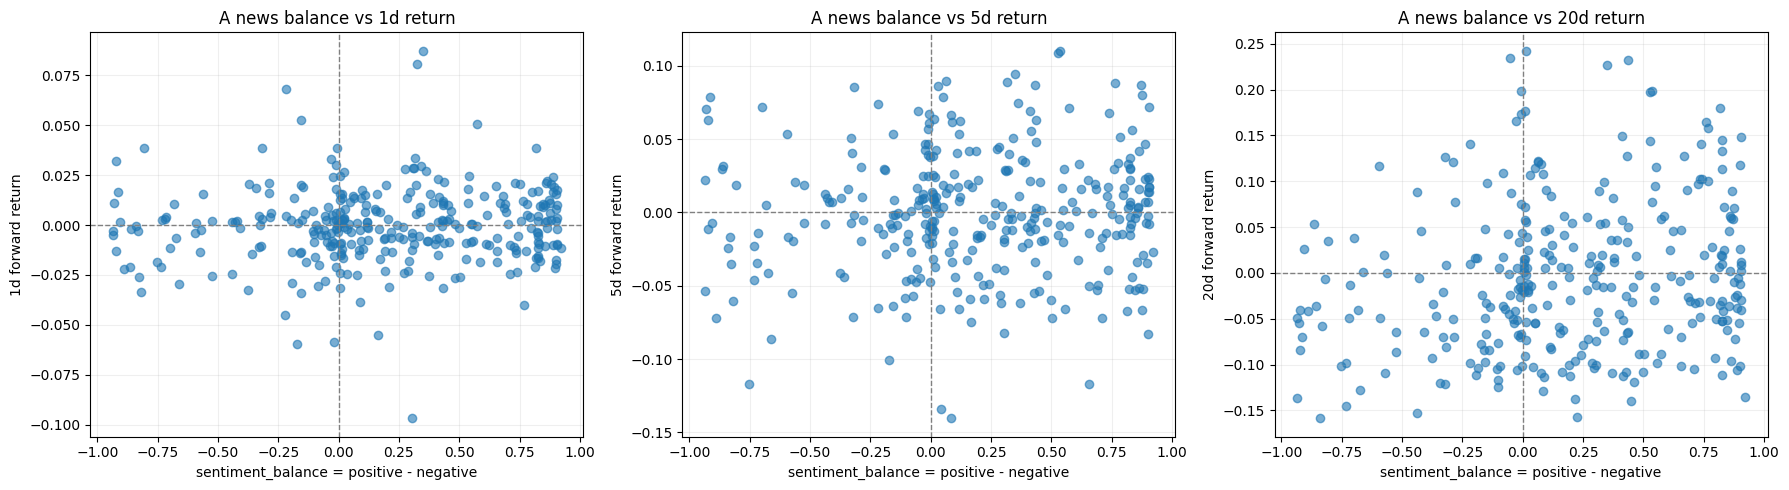

(    news_date market_date  news_count  positive_mean  negative_mean  \
 0  2010-04-15  2010-04-15           1       0.925926       0.038115   
 1  2012-05-15  2012-05-15           1       0.023623       0.160496   
 2  2013-08-12  2013-08-12           1       0.891085       0.035660   
 3  2013-11-15  2013-11-15           1       0.031634       0.128346   
 4  2014-06-27  2014-06-27           1       0.033824       0.010971   
 5  2015-01-06  2015-01-06           1       0.032171       0.019434   
 6  2016-05-17  2016-05-17           1       0.938794       0.034458   
 7  2018-08-14  2018-08-14           1       0.038207       0.121822   
 8  2018-10-25  2018-10-25           1       0.915865       0.050481   
 9  2019-03-28  2019-03-28           1       0.818953       0.133439   
 10 2019-04-17  2019-04-17           1       0.166451       0.053296   
 11 2022-09-11  2022-09-12           1       0.364027       0.584355   
 12 2022-09-15  2022-09-15           1       0.138125       0.10

In [25]:
price_df = ticker_to_df["a"][["Date", "Close"]].dropna(subset=["Date", "Close"]).sort_values("Date").copy()
price_df["Date"] = pd.to_datetime(price_df["Date"]).dt.normalize()
price_df["Close"] = price_df["Close"].astype(float)
price_df = price_df.drop_duplicates(subset=["Date"]).reset_index(drop=True)

daily_news = (
    news_sentiment_df.groupby("date_only", as_index=False)
    .agg(
        negative_mean=("negative", "mean"),
        positive_mean=("positive", "mean"),
        neutral_mean=("neutral", "mean"),
        sentiment_score_mean=("sentiment_score", "mean"),
        news_count=("Url", "count"),
        positive_articles=("sentiment", lambda s: (s == "positive").sum()),
        negative_articles=("sentiment", lambda s: (s == "negative").sum()),
        neutral_articles=("sentiment", lambda s: (s == "neutral").sum()),
    )
    .rename(columns={"date_only": "news_date"})
)
daily_news["sentiment_balance"] = daily_news["positive_mean"] - daily_news["negative_mean"]
daily_news["article_balance"] = daily_news["positive_articles"] - daily_news["negative_articles"]

aligned_news = pd.merge_asof(
    daily_news.sort_values("news_date"),
    price_df.rename(columns={"Date": "market_date", "Close": "close_t"}).sort_values("market_date"),
    left_on="news_date",
    right_on="market_date",
    direction="forward",
    allow_exact_matches=True,
).dropna(subset=["market_date", "close_t"]).reset_index(drop=True)

for horizon in [1, 5, 20]:
    forward_prices = price_df[["Date", "Close"]].copy()
    forward_prices[f"future_close_{horizon}d"] = forward_prices["Close"].shift(-horizon)
    forward_prices = forward_prices[["Date", f"future_close_{horizon}d"]].rename(columns={"Date": "market_date"})
    aligned_news = aligned_news.merge(forward_prices, on="market_date", how="left")
    aligned_news[f"return_{horizon}d"] = aligned_news[f"future_close_{horizon}d"] / aligned_news["close_t"] - 1.0
    aligned_news[f"trend_{horizon}d"] = pd.Series(np.where(aligned_news[f"return_{horizon}d"] > 0, "up", "down"), index=aligned_news.index)
    aligned_news.loc[aligned_news[f"return_{horizon}d"].isna(), f"trend_{horizon}d"] = pd.NA

aligned_news["predicted_trend"] = pd.Series(np.where(aligned_news["sentiment_balance"] >= 0, "up", "down"), index=aligned_news.index)

correlation_rows = []
for horizon in [1, 5, 20]:
    subset = aligned_news.dropna(subset=[f"return_{horizon}d"]).copy()
    correlation_rows.append({
        "horizon_days": horizon,
        "corr_positive_vs_return": subset["positive_mean"].corr(subset[f"return_{horizon}d"]),
        "corr_negative_vs_return": subset["negative_mean"].corr(subset[f"return_{horizon}d"]),
        "corr_balance_vs_return": subset["sentiment_balance"].corr(subset[f"return_{horizon}d"]),
        "directional_accuracy": (subset["predicted_trend"] == subset[f"trend_{horizon}d"]).mean(),
        "mean_return_when_positive_dominates": subset.loc[subset["sentiment_balance"] > 0, f"return_{horizon}d"].mean(),
        "mean_return_when_negative_dominates": subset.loc[subset["sentiment_balance"] < 0, f"return_{horizon}d"].mean(),
    })

sentiment_return_corr_df = pd.DataFrame(correlation_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, horizon in zip(axes, [1, 5, 20]):
    subset = aligned_news.dropna(subset=[f"return_{horizon}d"]).copy()
    ax.scatter(subset["sentiment_balance"], subset[f"return_{horizon}d"], alpha=0.6)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"A news balance vs {horizon}d return")
    ax.set_xlabel("sentiment_balance = positive - negative")
    ax.set_ylabel(f"{horizon}d forward return")
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

aligned_news[[
    "news_date",
    "market_date",
    "news_count",
    "positive_mean",
    "negative_mean",
    "sentiment_balance",
    "predicted_trend",
    "return_1d",
    "trend_1d",
    "return_5d",
    "trend_5d",
    "return_20d",
    "trend_20d",
]].head(30), sentiment_return_corr_df

In [26]:
sentiment_return_corr_df.round(4)

,horizon_days,corr_positive_vs_return,corr_negative_vs_return,corr_balance_vs_return,directional_accuracy,mean_return_when_positive_dominates,mean_return_when_negative_dominates
0,1,0.0497,-0.0740,0.0728,0.5248,0.0004,-0.0020
1,5,0.0207,-0.0746,0.0529,0.5171,0.0008,-0.0031
2,20,0.0947,-0.2280,0.1835,0.5524,0.0034,-0.0241


In [ ]:
# atencao cruzada entre moment e embeddings condicionados por prompt
# analise de dados inicial antes